# Whole-Dataset QC for Background Dominance (All Trials)

This notebook performs a whole-window QC analysis across **all trials and vessel types**.

Primary objective:
- Identify channels where background/control signal appears to dominate the biological signal.

Outputs:
- Per-unit QC evidence table
- Trial-level QC summary
- Saved CSV for reporting

In [1]:
import copy
import nbformat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path('/Users/oakley/Documents/GitHub/signal_respirometry')
SOURCE_NOTEBOOK = ROOT / 'notebooks' / 'A_batch_respirometry_final.ipynb'
OUT_DIR = ROOT / 'data' / 'processed'

# Tunable QC thresholds.
RATIO_MIN = 0.03
WEAK_DIFF_SLOPE_RATIO_MAX = 0.25
MIN_POINTS = 5

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Source notebook: {SOURCE_NOTEBOOK}')
print(f'Output directory: {OUT_DIR}')
print(f'RATIO_MIN={RATIO_MIN}, WEAK_DIFF_SLOPE_RATIO_MAX={WEAK_DIFF_SLOPE_RATIO_MAX}')

Source notebook: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/A_batch_respirometry_final.ipynb
Output directory: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed
RATIO_MIN=0.03, WEAK_DIFF_SLOPE_RATIO_MAX=0.25


In [5]:
# Load run definitions from the batch notebook.
nb = nbformat.read(SOURCE_NOTEBOOK, as_version=4)
code_cells = [c for c in nb.cells if c.cell_type == 'code']

function_cell_idx = None
for idx, c in enumerate(code_cells):
    if 'def run_respirometry_analysis(' in c.source:
        function_cell_idx = idx
        break

if function_cell_idx is None:
    raise ValueError('Could not find run_respirometry_analysis in source notebook.')

ns = {}
for c in code_cells[: function_cell_idx + 1]:
    exec(c.source, ns)

if 'runs' not in ns:
    raise ValueError('Source notebook did not produce a runs list.')

all_runs = copy.deepcopy(ns['runs'])
DEFAULT_CHANNELS = ns.get('DEFAULT_CHANNELS', ['Ch2', 'Ch3', 'Ch4'])

runs_df = pd.DataFrame([
    {
        'trial': r.get('trial'),
        'brick': r.get('brick'),
        'csv': str(r.get('csv')),
        'control_csv': str(r.get('control_csv')) if r.get('control_csv') is not None else None,
        'control': r.get('control', 'Ch1'),
        'start_hour': r.get('start_hour', 1),
        'end_hour': r.get('end_hour', 8),
        'vessel': r.get('metadata', {}).get('vessel'),
        'environment': r.get('metadata', {}).get('environment'),
    }
    for r in all_runs
])

print(f'Total runs loaded: {len(all_runs)}')
display(runs_df.head(20))

Total runs: 25

Runs by trial:
  trial1: 3 run(s)
  trial2: 1 run(s)
  trial3: 3 run(s)
  trial4: 3 run(s)
  trial4.5: 2 run(s)
  trial5: 3 run(s)
  trial5.5: 2 run(s)
  trial6: 2 run(s)
  trial6.5: 2 run(s)
  trial7: 2 run(s)
  trial7.5: 2 run(s)
Total runs loaded: 25


,trial,brick,csv,control_csv,control,start_hour,end_hour,vessel,environment
0,trial1,box2,/Users/oakley/Documents/GitHub/signal_respirom...,None,Ch1,1,8,small,night
1,trial1,box3,/Users/oakley/Documents/GitHub/signal_respirom...,None,Ch1,1,8,cylinder,night
2,trial1,newbox,/Users/oakley/Documents/GitHub/signal_respirom...,None,Ch1,1,8,small,night
3,trial2,newbox,/Users/oakley/Documents/GitHub/signal_respirom...,None,Ch1,1,8,medium,night
4,trial3,box2,/Users/oakley/Documents/GitHub/signal_respirom...,None,Ch1,1,8,cylinder,night
5,trial3,box3,/Users/oakley/Documents/GitHub/signal_respirom...,None,Ch1,1,8,medium,night
6,trial3,newbox,/Users/oakley/Documents/GitHub/signal_respirom...,None,Ch1,1,8,small,night
7,trial4,box2,/Users/oakley/Documents/GitHub/signal_respirom...,None,Ch1,1,8,small,night
8,trial4,box3,/Users/oakley/Documents/GitHub/signal_respirom...,None,Ch1,1,8,small,night
9,trial4,newbox,/Users/oakley/Documents/GitHub/signal_respirom...,None,Ch1,1,8,cylinder,night


In [6]:
# Build whole-window signal/background evidence for all runs.
rows = []
warnings = []

for run in all_runs:
    trial = run.get('trial', 'unknown_trial')
    brick = run.get('brick', 'unknown_brick')
    metadata = run.get('metadata', {})
    vessel = metadata.get('vessel')
    environment = metadata.get('environment')

    exp_path = run.get('csv', None)
    ctrl_path = run.get('control_csv', exp_path)
    control_ch = run.get('control', 'Ch1')
    channels = list(run.get('channels', DEFAULT_CHANNELS))
    start_h = float(run.get('start_hour', 1))
    end_h = float(run.get('end_hour', 8))

    if exp_path is None or ctrl_path is None:
        warnings.append(f'{trial}-{brick}: missing csv/control_csv path')
        continue

    try:
        exp_df = pd.read_csv(exp_path)
        ctrl_df = pd.read_csv(ctrl_path)
    except Exception as exc:
        warnings.append(f'{trial}-{brick}: failed reading csvs ({exc})')
        continue

    if 'hours' not in exp_df.columns or 'hours' not in ctrl_df.columns:
        warnings.append(f'{trial}-{brick}: missing hours column in csv/control_csv')
        continue
    if control_ch not in ctrl_df.columns:
        warnings.append(f'{trial}-{brick}: control column {control_ch} missing in control_csv')
        continue

    exp_win = exp_df[(exp_df['hours'] >= start_h) & (exp_df['hours'] <= end_h)].copy()
    ctrl_win = ctrl_df[(ctrl_df['hours'] >= start_h) & (ctrl_df['hours'] <= end_h)].copy()
    if len(exp_win) < MIN_POINTS or len(ctrl_win) < MIN_POINTS:
        warnings.append(f'{trial}-{brick}: insufficient rows in analysis window {start_h}-{end_h}h')
        continue

    control_base = ctrl_win[['hours', control_ch]].dropna().rename(columns={control_ch: 'control_value'})
    if len(control_base) < MIN_POINTS:
        warnings.append(f'{trial}-{brick}: insufficient control rows after NA filtering')
        continue

    control_slope = float(np.polyfit(
        control_base['hours'].to_numpy(dtype=float),
        control_base['control_value'].to_numpy(dtype=float),
        1,
    )[0])
    control_mean = float(control_base['control_value'].mean())

    for ch in channels:
        if ch not in exp_win.columns:
            continue

        ch_df = exp_win[['hours', ch]].dropna().rename(columns={ch: 'channel_value'})
        merged = control_base.merge(ch_df, on='hours', how='inner').sort_values('hours').reset_index(drop=True)
        if len(merged) < MIN_POINTS:
            warnings.append(f'{trial}-{brick}-{ch}: insufficient aligned points')
            continue

        merged['channel_minus_control'] = merged['channel_value'] - merged['control_value']

        channel_slope = float(np.polyfit(
            merged['hours'].to_numpy(dtype=float),
            merged['channel_value'].to_numpy(dtype=float),
            1,
        )[0])
        diff_slope = float(np.polyfit(
            merged['hours'].to_numpy(dtype=float),
            merged['channel_minus_control'].to_numpy(dtype=float),
            1,
        )[0])
        diff_mean = float(merged['channel_minus_control'].mean())
        diff_min = float(merged['channel_minus_control'].min())
        diff_max = float(merged['channel_minus_control'].max())

        rows.append({
            'trial': str(trial),
            'brick': str(brick),
            'channel': str(ch),
            'unit': f'{trial} | {brick} | {ch}',
            'vessel': vessel,
            'environment': environment,
            'start_hour': start_h,
            'end_hour': end_h,
            'n_points': int(len(merged)),
            'control_mean': control_mean,
            'control_slope_per_hour': control_slope,
            'channel_slope_per_hour': channel_slope,
            'diff_mean': diff_mean,
            'diff_min': diff_min,
            'diff_max': diff_max,
            'diff_slope_per_hour': diff_slope,
            'source_csv': str(exp_path),
            'source_control_csv': str(ctrl_path),
        })

qc_evidence_df = pd.DataFrame(rows).sort_values(['trial', 'brick', 'channel']).reset_index(drop=True)
if qc_evidence_df.empty:
    raise ValueError('No QC evidence rows produced. Check inputs and window coverage.')

if warnings:
    print('Warnings:')
    for w in warnings:
        print(' -', w)

print(f'QC evidence rows: {len(qc_evidence_df)}')
display(qc_evidence_df.head(30))

Warnings:
 - trial5.5-box3-Ch2: insufficient aligned points
 - trial5.5-box3-Ch3: insufficient aligned points
 - trial5.5-box3-Ch4: insufficient aligned points
 - trial6-box3-Ch2: insufficient aligned points
 - trial6-box3-Ch3: insufficient aligned points
 - trial6-box3-Ch4: insufficient aligned points
 - trial7-box3-Ch2: insufficient aligned points
 - trial7-box3-Ch3: insufficient aligned points
 - trial7-box3-Ch4: insufficient aligned points
 - trial7.5-box3-Ch2: insufficient aligned points
 - trial7.5-box3-Ch3: insufficient aligned points
 - trial7.5-box3-Ch4: insufficient aligned points
QC evidence rows: 59


,trial,brick,channel,unit,vessel,environment,start_hour,end_hour,n_points,control_mean,control_slope_per_hour,channel_slope_per_hour,diff_mean,diff_min,diff_max,diff_slope_per_hour,source_csv,source_control_csv
0,trial1,box2,Ch2,trial1 | box2 | Ch2,small,night,1.0,8.0,12156,179.733190,-4.766356,-13.651514,-54.213588,-77.581000,-18.580000,-8.885158,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...
1,trial1,box2,Ch3,trial1 | box2 | Ch3,small,night,1.0,8.0,12156,179.733190,-4.766356,-16.815193,-38.559303,-81.848000,-5.390000,-12.048837,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...
2,trial1,box2,Ch4,trial1 | box2 | Ch4,small,night,1.0,8.0,12156,179.733190,-4.766356,-17.226976,-29.488929,-62.559000,11.320000,-12.460621,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...
3,trial1,box3,Ch2,trial1 | box3 | Ch2,cylinder,night,1.0,8.0,12101,193.660228,-2.644310,-10.339702,-25.603724,-52.630000,-3.140000,-7.695392,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...
4,trial1,box3,Ch3,trial1 | box3 | Ch3,cylinder,night,1.0,8.0,12101,193.660228,-2.644310,-10.185860,-33.544456,-54.140000,-6.500000,-7.541550,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...
5,trial1,box3,Ch4,trial1 | box3 | Ch4,cylinder,night,1.0,8.0,12101,193.660228,-2.644310,-9.491351,-27.905084,-45.620000,-2.510000,-6.847041,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...
6,trial1,newbox,Ch2,trial1 | newbox | Ch2,small,night,1.0,8.0,12599,192.980424,-4.963388,-15.328585,-45.093785,-77.110000,-12.567000,-10.365197,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...
7,trial1,newbox,Ch3,trial1 | newbox | Ch3,small,night,1.0,8.0,12599,192.980424,-4.963388,-16.217876,-62.361563,-104.437000,-25.868000,-11.254487,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...
8,trial1,newbox,Ch4,trial1 | newbox | Ch4,small,night,1.0,8.0,12599,192.980424,-4.963388,-17.636410,-65.732306,-103.938000,-24.431000,-12.673021,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...
9,trial2,newbox,Ch2,trial2 | newbox | Ch2,medium,night,1.0,8.0,5040,190.017943,-2.768994,-8.032617,-26.917843,-45.084000,-9.176000,-5.263623,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...


In [7]:
# Merge with batch summary (whole analysis output) and compute QC flags.
batch_summary_path = OUT_DIR / 'batch_summary.csv'
if not batch_summary_path.exists():
    raise FileNotFoundError(f'Batch summary not found: {batch_summary_path}')

batch_df = pd.read_csv(batch_summary_path)
batch_df['trial'] = batch_df['trial'].astype(str)
batch_df['brick'] = batch_df['brick'].astype(str)
batch_df['channel'] = batch_df['channel'].astype(str)

merge_cols = ['trial', 'brick', 'channel']
qc_df = qc_evidence_df.merge(
    batch_df[merge_cols + ['RMR']].rename(columns={'RMR': 'RMR_corrected'}),
    on=merge_cols,
    how='left',
)

eps = 1e-9
qc_df['abs_diff_mean'] = np.abs(qc_df['diff_mean'])
qc_df['signal_to_background_ratio'] = qc_df['abs_diff_mean'] / (np.abs(qc_df['control_mean']) + eps)
qc_df['diff_to_control_slope_ratio'] = np.abs(qc_df['diff_slope_per_hour']) / (np.abs(qc_df['control_slope_per_hour']) + eps)

qc_df['flag_ratio_low'] = qc_df['signal_to_background_ratio'] < RATIO_MIN
qc_df['flag_crosses_zero'] = (qc_df['diff_min'] <= 0) & (qc_df['diff_max'] >= 0)
qc_df['flag_negative_corrected_rmr'] = qc_df['RMR_corrected'] <= 0
qc_df['flag_weak_diff_slope'] = qc_df['diff_to_control_slope_ratio'] < WEAK_DIFF_SLOPE_RATIO_MAX

# Conservative exclusion rule for whole-window QC.
qc_df['qc_exclude'] = (
    qc_df['flag_negative_corrected_rmr']
    | (qc_df['flag_ratio_low'] & (qc_df['flag_crosses_zero'] | qc_df['flag_weak_diff_slope']))
)
qc_df['qc_recommendation'] = np.where(qc_df['qc_exclude'], 'exclude', 'include')

def reason(row):
    rs = []
    if bool(row['flag_negative_corrected_rmr']):
        rs.append('corrected_rmr<=0')
    if bool(row['flag_ratio_low']):
        rs.append('low_signal_to_background')
    if bool(row['flag_crosses_zero']):
        rs.append('channel_minus_control_crosses_0')
    if bool(row['flag_weak_diff_slope']):
        rs.append('weak_channel_minus_control_slope')
    return '; '.join(rs) if rs else 'none'

qc_df['qc_reason'] = qc_df.apply(reason, axis=1)

qc_df = qc_df.sort_values(['trial', 'brick', 'channel']).reset_index(drop=True)
display(qc_df.head(50))

,trial,brick,channel,unit,vessel,environment,start_hour,end_hour,n_points,control_mean,...,abs_diff_mean,signal_to_background_ratio,diff_to_control_slope_ratio,flag_ratio_low,flag_crosses_zero,flag_negative_corrected_rmr,flag_weak_diff_slope,qc_exclude,qc_recommendation,qc_reason
0,trial1,box2,Ch2,trial1 | box2 | Ch2,small,night,1.0,8.0,12156,179.733190,...,54.213588,0.301634,1.864141,False,False,False,False,False,include,none
1,trial1,box2,Ch3,trial1 | box2 | Ch3,small,night,1.0,8.0,12156,179.733190,...,38.559303,0.214536,2.527893,False,False,False,False,False,include,none
2,trial1,box2,Ch4,trial1 | box2 | Ch4,small,night,1.0,8.0,12156,179.733190,...,29.488929,0.164071,2.614287,False,True,False,False,False,include,channel_minus_control_crosses_0
3,trial1,box3,Ch2,trial1 | box3 | Ch2,cylinder,night,1.0,8.0,12101,193.660228,...,25.603724,0.132210,2.910170,False,False,False,False,False,include,none
4,trial1,box3,Ch3,trial1 | box3 | Ch3,cylinder,night,1.0,8.0,12101,193.660228,...,33.544456,0.173213,2.851992,False,False,False,False,False,include,none
5,trial1,box3,Ch4,trial1 | box3 | Ch4,cylinder,night,1.0,8.0,12101,193.660228,...,27.905084,0.144093,2.589349,False,False,False,False,False,include,none
6,trial1,newbox,Ch2,trial1 | newbox | Ch2,small,night,1.0,8.0,12599,192.980424,...,45.093785,0.233670,2.088331,False,False,False,False,False,include,none
7,trial1,newbox,Ch3,trial1 | newbox | Ch3,small,night,1.0,8.0,12599,192.980424,...,62.361563,0.323150,2.267501,False,False,False,False,False,include,none
8,trial1,newbox,Ch4,trial1 | newbox | Ch4,small,night,1.0,8.0,12599,192.980424,...,65.732306,0.340616,2.553300,False,False,False,False,False,include,none
9,trial2,newbox,Ch2,trial2 | newbox | Ch2,medium,night,1.0,8.0,5040,190.017943,...,26.917843,0.141659,1.900915,False,False,False,False,False,include,none


In [8]:
# Summaries and save outputs.
trial_summary_df = qc_df.groupby('trial').agg(
    n_units=('channel', 'size'),
    frac_excluded=('qc_exclude', 'mean'),
    mean_signal_to_background_ratio=('signal_to_background_ratio', 'mean'),
    median_signal_to_background_ratio=('signal_to_background_ratio', 'median'),
    mean_corrected_rmr=('RMR_corrected', 'mean'),
).reset_index().sort_values(['frac_excluded', 'mean_signal_to_background_ratio'], ascending=[False, True])

print('QC recommendation counts:')
display(qc_df['qc_recommendation'].value_counts().rename_axis('qc_recommendation').reset_index(name='n'))

print('Trial-level QC summary:')
display(trial_summary_df)

qc_out = OUT_DIR / 'batch_qc_all_trials_wholenight.csv'
trial_out = OUT_DIR / 'batch_qc_all_trials_trial_summary.csv'
qc_df.to_csv(qc_out, index=False)
trial_summary_df.to_csv(trial_out, index=False)
print(f'Saved QC table: {qc_out}')
print(f'Saved trial summary: {trial_out}')

QC recommendation counts:


,qc_recommendation,n
0,include,57
1,exclude,2


Trial-level QC summary:


,trial,n_units,frac_excluded,mean_signal_to_background_ratio,median_signal_to_background_ratio,mean_corrected_rmr
3,trial4,8,0.25,0.133074,0.132301,0.821711
4,trial4.5,5,0.00,0.087793,0.099622,1.234515
5,trial5,8,0.00,0.103282,0.099959,2.006292
9,trial7,3,0.00,0.126858,0.119755,1.450488
2,trial3,9,0.00,0.135158,0.122178,3.039551
1,trial2,3,0.00,0.171699,0.149320,4.006850
6,trial5.5,3,0.00,0.175446,0.145833,1.650394
8,trial6.5,5,0.00,0.180313,0.171182,2.160962
7,trial6,3,0.00,0.211853,0.215303,1.363608
0,trial1,9,0.00,0.225244,0.214536,4.803045


Saved QC table: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_qc_all_trials_wholenight.csv
Saved trial summary: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_qc_all_trials_trial_summary.csv


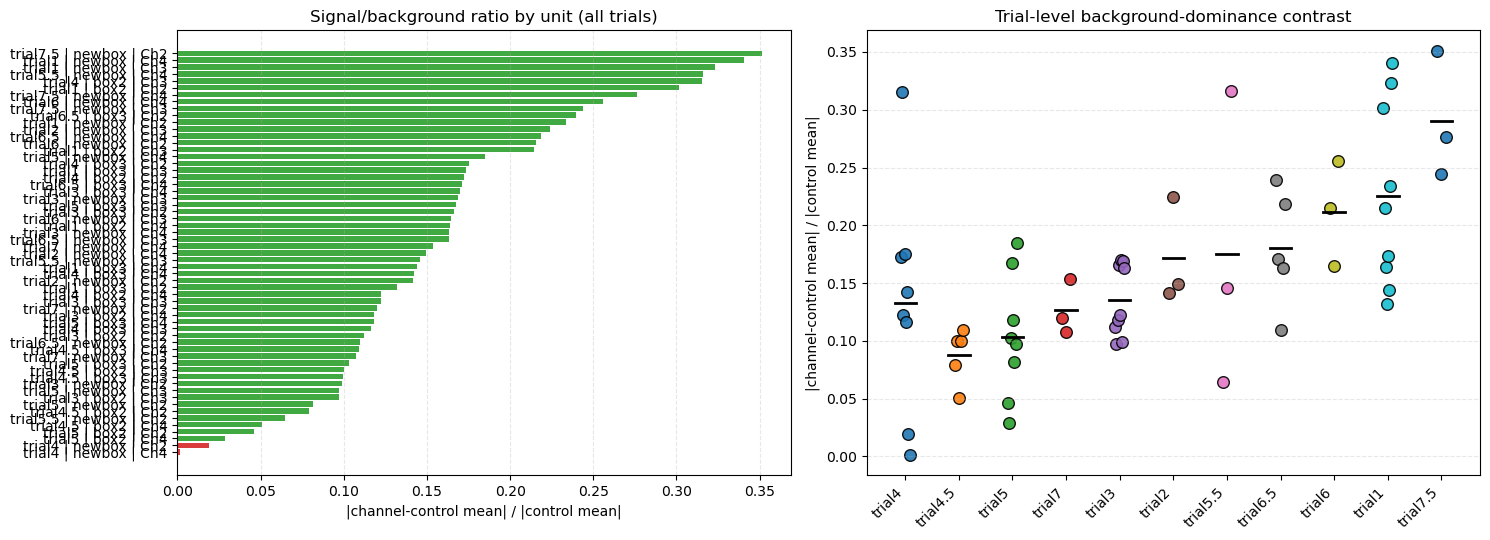

In [9]:
# Visual diagnostics.
plot_df = qc_df.sort_values('signal_to_background_ratio').copy()
colors = np.where(plot_df['qc_exclude'], '#d62728', '#2ca02c')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].barh(np.arange(len(plot_df)), plot_df['signal_to_background_ratio'], color=colors, alpha=0.9)
axes[0].set_yticks(np.arange(len(plot_df)))
axes[0].set_yticklabels(plot_df['unit'])
axes[0].set_xlabel('|channel-control mean| / |control mean|')
axes[0].set_title('Signal/background ratio by unit (all trials)')
axes[0].grid(True, axis='x', linestyle='--', alpha=0.3)

trial_order = list(trial_summary_df['trial'])
for i, tr in enumerate(trial_order):
    d = qc_df[qc_df['trial'] == tr]
    if d.empty:
        continue
    jitter = np.linspace(-0.08, 0.08, len(d)) if len(d) > 1 else np.array([0.0])
    axes[1].scatter(np.full(len(d), i) + jitter, d['signal_to_background_ratio'], s=70, alpha=0.9, edgecolor='black')
    m = float(d['signal_to_background_ratio'].mean())
    axes[1].plot([i - 0.2, i + 0.2], [m, m], color='black', linewidth=2)

axes[1].set_xticks(range(len(trial_order)))
axes[1].set_xticklabels(trial_order, rotation=45, ha='right')
axes[1].set_ylabel('|channel-control mean| / |control mean|')
axes[1].set_title('Trial-level background-dominance contrast')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Notes for Reporting

- This QC is computed on each run's configured analysis window (typically long windows).
- `signal_to_background_ratio` is interpreted as effective biological contrast relative to control baseline.
- Exclusion combines low contrast with unstable channel-control behavior and/or non-positive corrected RMR.
- Thresholds (`RATIO_MIN`, `WEAK_DIFF_SLOPE_RATIO_MAX`) are user-adjustable and should be documented.